**In case of problems or questions, please first check the list of [Frequently Asked Questions (FAQ)](https://stardist.net/docs/faq.html).**

Please shutdown all other training/prediction notebooks before running this notebook (as those might occupy the GPU memory otherwise).

In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from glob import glob
from tqdm import tqdm
from tifffile import imread
from csbdeep.utils import Path, normalize

from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D

np.random.seed(42)
lbl_cmap = random_label_cmap()

2026-05-08 09:02:05.286497: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 09:02:05.300416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 09:02:05.314644: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 09:02:05.318841: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 09:02:05.331098: I tensorflow/core/platform/cpu_feature_guar

# Data

We assume that data has already been downloaded via notebook [1_data.ipynb](1_data.ipynb).  

<div class="alert alert-block alert-info">
Training data (for input `X` with associated label masks `Y`) can be provided via lists of numpy arrays, where each image can have a different size. Alternatively, a single numpy array can also be used if all images have the same size.  
Input images can either be two-dimensional (single-channel) or three-dimensional (multi-channel) arrays, where the channel axis comes last. Label images need to be integer-valued.
</div>

In [2]:
import shutil
from pathlib import Path

def prepare_stardist_dataset(src_dir, dst_dir):
    src_dir, dst_dir = Path(src_dir), Path(dst_dir)
    
    # Wyczyść jeśli istnieje
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    
    (dst_dir/'images').mkdir(parents=True, exist_ok=True)
    (dst_dir/'masks').mkdir(parents=True, exist_ok=True)

    for img in sorted(src_dir.glob('*_image.jpg')):
        new_name = img.stem.replace('_image', '') + img.suffix
        shutil.copy(img, dst_dir/'images'/new_name)

    for msk in sorted(src_dir.glob('*_masks.tif')):
        new_name = msk.stem.replace('_masks', '') + msk.suffix
        shutil.copy(msk, dst_dir/'masks'/new_name)

    X = sorted((dst_dir/'images').glob('*.jpg'))
    Y = sorted((dst_dir/'masks').glob('*.tif'))

    print(f"Znaleziono: {len(X)} obrazów | {len(Y)} masek")  # debug

    assert len(X) == len(Y), f"Różna liczba obrazów i masek w {dst_dir}!"
    assert all(Path(x).stem == Path(y).stem for x, y in zip(X, Y)), "Niedopasowane pary!"
    
    print(f"{dst_dir.name}: {len(X)} par — OK ✓")
    return X, Y

Train data

In [3]:
X_trn, Y_trn = prepare_stardist_dataset(
    src_dir = '/workspace/dane/dane_treningowe/AS_GRUPA1/train',
    dst_dir = 'stardist-train'
)

Znaleziono: 457 obrazów | 457 masek
stardist-train: 457 par — OK ✓


In [5]:
from skimage.io import imread as sk_imread

In [6]:
X_trn = list(map(sk_imread,X_trn))
Y_trn = list(map(imread,Y_trn))
n_channel = 1 if X_trn[0].ndim == 2 else X_trn[0].shape[-1]

Normalize images and fill small label holes.

In [7]:
axis_norm = (0,1)   # normalize channels independently
# axis_norm = (0,1,2) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))
    sys.stdout.flush()

X_trn = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X_trn)]
Y_trn = [fill_label_holes(y) for y in tqdm(Y_trn)]

Normalizing image channels independently.


100%|███████████████████████████████████████████████████████████████| 457/457 [00:09<00:00, 46.67it/s]


Test data

In [8]:
X_val, Y_val = prepare_stardist_dataset(
    src_dir = '/workspace/dane/dane_treningowe/AS_GRUPA1/test',
    dst_dir = 'stardist-test'
)

Znaleziono: 128 obrazów | 128 masek
stardist-test: 128 par — OK ✓


In [11]:
X_val = list(map(sk_imread,X_val))
Y_val = list(map(imread,Y_val))
n_channel = 1 if X_val[0].ndim == 2 else X_val[0].shape[-1]

In [12]:
axis_norm = (0,1)   # normalize channels independently
# axis_norm = (0,1,2) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))
    sys.stdout.flush()

X_val = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X_val)]
Y_val = [fill_label_holes(y) for y in tqdm(Y_val)]

Normalizing image channels independently.


100%|███████████████████████████████████████████████████████████████| 128/128 [00:02<00:00, 47.80it/s]


Split into train and validation datasets.

In [14]:
def plot_img_label(img, lbl, img_title="image", lbl_title="label", **kwargs):
    fig, (ai,al) = plt.subplots(1,2, figsize=(12,5), gridspec_kw=dict(width_ratios=(1.25,1)))
    im = ai.imshow(img, cmap='gray', clim=(0,1))
    ai.set_title(img_title)    
    fig.colorbar(im, ax=ai)
    al.imshow(lbl, cmap=lbl_cmap)
    al.set_title(lbl_title)
    plt.tight_layout()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22772278..1.6831683].


9


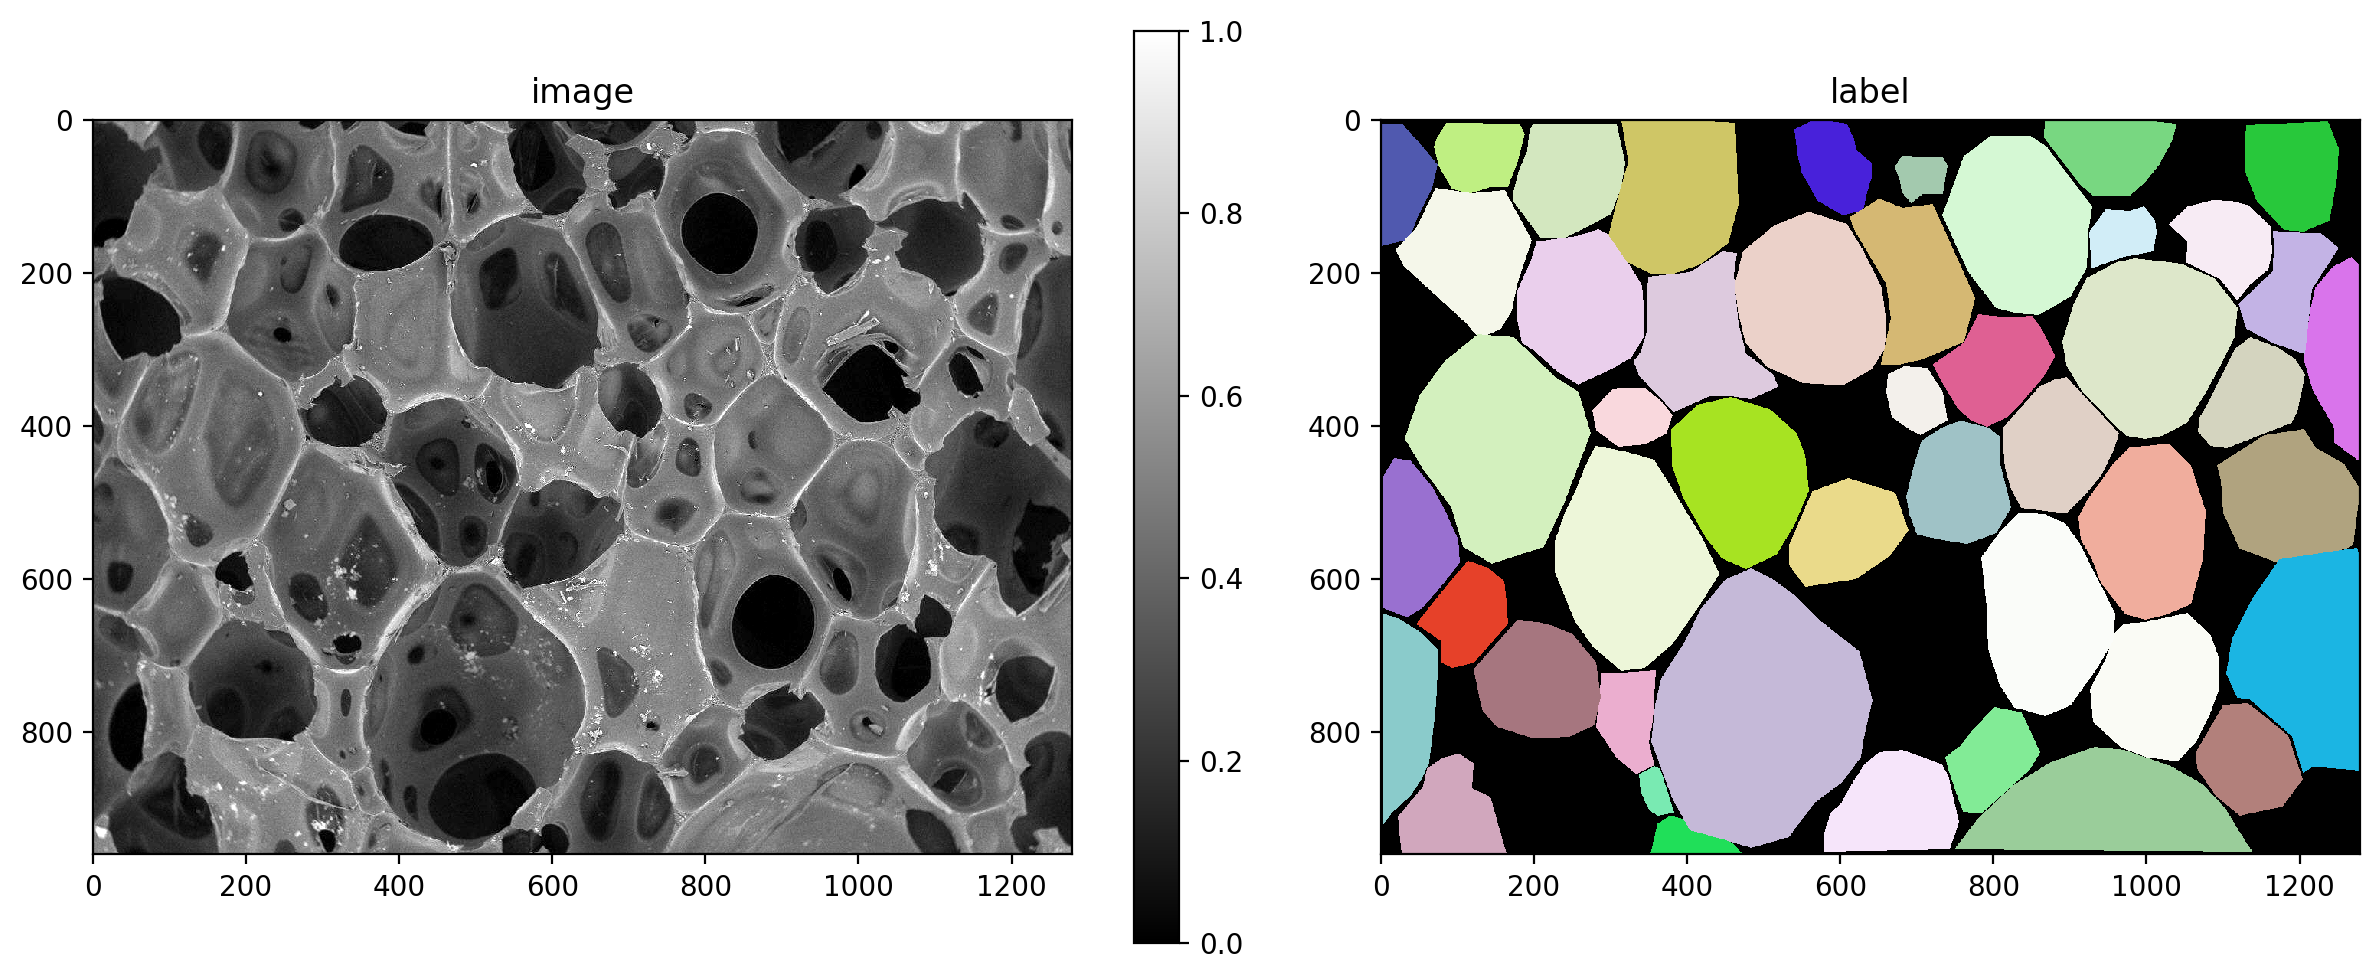

In [15]:
i = min(9, len(X_trn)-1)
print(i)
img, lbl = X_trn[i], Y_trn[i]
assert img.ndim in (2,3)
img = img if (img.ndim==2 or img.shape[-1]==3) else img[...,0]
plot_img_label(img,lbl)
None;

# Configuration

A `StarDist2D` model is specified via a `Config2D` object.

In [16]:
print(Config2D.__doc__)

Configuration for a :class:`StarDist2D` model.

    Parameters
    ----------
    axes : str or None
        Axes of the input images.
    n_rays : int
        Number of radial directions for the star-convex polygon.
        Recommended to use a power of 2 (default: 32).
    n_channel_in : int
        Number of channels of given input image (default: 1).
    grid : (int,int)
        Subsampling factors (must be powers of 2) for each of the axes.
        Model will predict on a subsampled grid for increased efficiency and larger field of view.
    n_classes : None or int
        Number of object classes to use for multi-class prediction (use None to disable)
    backbone : str
        Name of the neural network architecture to be used as backbone.
    kwargs : dict
        Overwrite (or add) configuration attributes (see below).


    Attributes
    ----------
    unet_n_depth : int
        Number of U-Net resolution levels (down/up-sampling layers).
    unet_kernel_size : (int,int)
   

In [17]:
X_trn = [x[:, :, 0] for x in X_trn]
X_val = [x[:, :, 0] for x in X_val]

In [18]:
# MY PARAMETERS
axes = 'YX'

n_channel_in = 1

n_classes = None

use_gpu = False  # it is not related with training

# MY ATTRIBUTES
train_shape_completion = False

# NEED TO BE ADJUSTED BASED OF SCALE OF OBJECTS ON THE IMAGES
# unet_n_depth = 5
unet_kernel_size = (5, 5)

n_rays = 32

# Use OpenCL-based computations for data generator during training (requires 'gputools')
# use_gpu = False and gputools_available()

grid = (4, 4)

conf = Config2D (
    axes = axes,
    # n_channel_in = n_channel_in,
    n_classes=n_classes,
    train_shape_completion=train_shape_completion,
    n_rays       = n_rays,
    grid         = grid,
    use_gpu      = use_gpu,
    unet_kernel_size = unet_kernel_size,
    # unet_n_depth = unet_n_depth
    n_channel_in = n_channel_in,
)
print(conf)
vars(conf)

Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(4, 4), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(5, 5), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=(256, 256), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 40,

{'n_dim': 2,
 'axes': 'YXC',
 'n_channel_in': 1,
 'n_channel_out': 33,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'n_rays': 32,
 'grid': (4, 4),
 'backbone': 'unet',
 'n_classes': None,
 'unet_n_depth': 3,
 'unet_kernel_size': (5, 5),
 'unet_n_filter_base': 32,
 'unet_n_conv_per_depth': 2,
 'unet_pool': (2, 2),
 'unet_activation': 'relu',
 'unet_last_activation': 'relu',
 'unet_batch_norm': False,
 'unet_dropout': 0.0,
 'unet_expansion': 2,
 'unet_prefix': '',
 'net_conv_after_unet': 128,
 'net_input_shape': (None, None, 1),
 'net_mask_shape': (None, None, 1),
 'train_shape_completion': False,
 'train_completion_crop': 32,
 'train_patch_size': (256, 256),
 'train_background_reg': 0.0001,
 'train_foreground_only': 0.9,
 'train_sample_cache': True,
 'train_dist_loss': 'mae',
 'train_loss_weights': (1, 0.2),
 'train_class_weights': (1, 1),
 'train_epochs': 400,
 'train_steps_per_epoch': 100,
 'train_le

In [19]:
if use_gpu:
    from csbdeep.utils.tf import limit_gpu_memory
    # adjust as necessary: limit GPU memory to be used by TensorFlow to leave some to OpenCL-based computations
#     limit_gpu_memory(0.8)
    # alternatively, try this:
    limit_gpu_memory(None, allow_growth=True)

In [20]:
print(conf)
print(f"Train: {len(X_trn)}, Val: {len(X_val)}")
print(f"Sample image shape: {X_trn[0].shape if hasattr(X_trn[0], 'shape') else 'path'}")

Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(4, 4), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(5, 5), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=(256, 256), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 40,

**Note:** The trained `StarDist2D` model will *not* predict completed shapes for partially visible objects at the image boundary if `train_shape_completion=False` (which is the default option).

In [21]:
if Path('models/stardist').exists():
    shutil.rmtree('models/stardist')

In [22]:
model = StarDist2D(conf, name='stardist', basedir='models')

I0000 00:00:1778230970.245112     337 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778230970.674542     337 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778230970.674591     337 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778230970.677746     337 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778230970.677784     337 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Using default values: prob_thresh=0.5, nms_thresh=0.4.


5090, pci bus id: 0000:01:00.0, compute capability: 12.0


In [23]:
print("Config w modelu:")
print(f"  unet_kernel_size: {model.config.unet_kernel_size}")
print(f"  unet_n_depth:     {model.config.unet_n_depth}")
print(f"  grid:             {model.config.grid}")
print(f"  unet_pool:        {model.config.unet_pool}")

Config w modelu:
  unet_kernel_size: (5, 5)
  unet_n_depth:     3
  grid:             (4, 4)
  unet_pool:        (2, 2)


Check if the neural network has a large enough field of view to see up to the boundary of most objects.

In [24]:
median_size = calculate_extents(list(Y_trn), np.median)
fov = np.array(model._axes_tile_overlap('YX'))
print(f"median object size:      {median_size}")
print(f"network field of view :  {fov}")
if any(median_size > fov):
    print("WARNING: median object size larger than field of view of the neural network.")

2026-05-08 09:02:54.181543: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1778230974.374508     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.415186     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.415532     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.416049     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.416469     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.434824     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.448860     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230974.450868     423 gpu_

median object size:      [142.5 133. ]
network field of view :  [256 256]


W0000 00:00:1778230975.376836     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.377151     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.377405     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.377738     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.378295     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.378808     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.379084     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.379278     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778230975.379549     421 gp

# Data Augmentation

You can define a function/callable that applies augmentation to each batch of the data generator.  
We here use an `augmenter` that applies random rotations, flips, and intensity changes, which are typically sensible for (2D) microscopy images (but you can disable augmentation by setting `augmenter = None`).

In [25]:
def random_fliprot(img, mask): 
    assert img.ndim >= mask.ndim
    axes = tuple(range(mask.ndim))
    perm = tuple(np.random.permutation(axes))
    img = img.transpose(perm + tuple(range(mask.ndim, img.ndim))) 
    mask = mask.transpose(perm) 
    for ax in axes: 
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask 

def random_intensity_change(img):
    img = img*np.random.uniform(0.6,2) + np.random.uniform(-0.2,0.2)
    return img


def augmenter(x, y):
    """Augmentation of a single input/label image pair.
    x is an input image
    y is the corresponding ground-truth label image
    """
    x, y = random_fliprot(x, y)
    x = random_intensity_change(x)
    # add some gaussian noise
    sig = 0.02*np.random.uniform(0,1)
    x = x + sig*np.random.normal(0,1,x.shape)
    return x, y

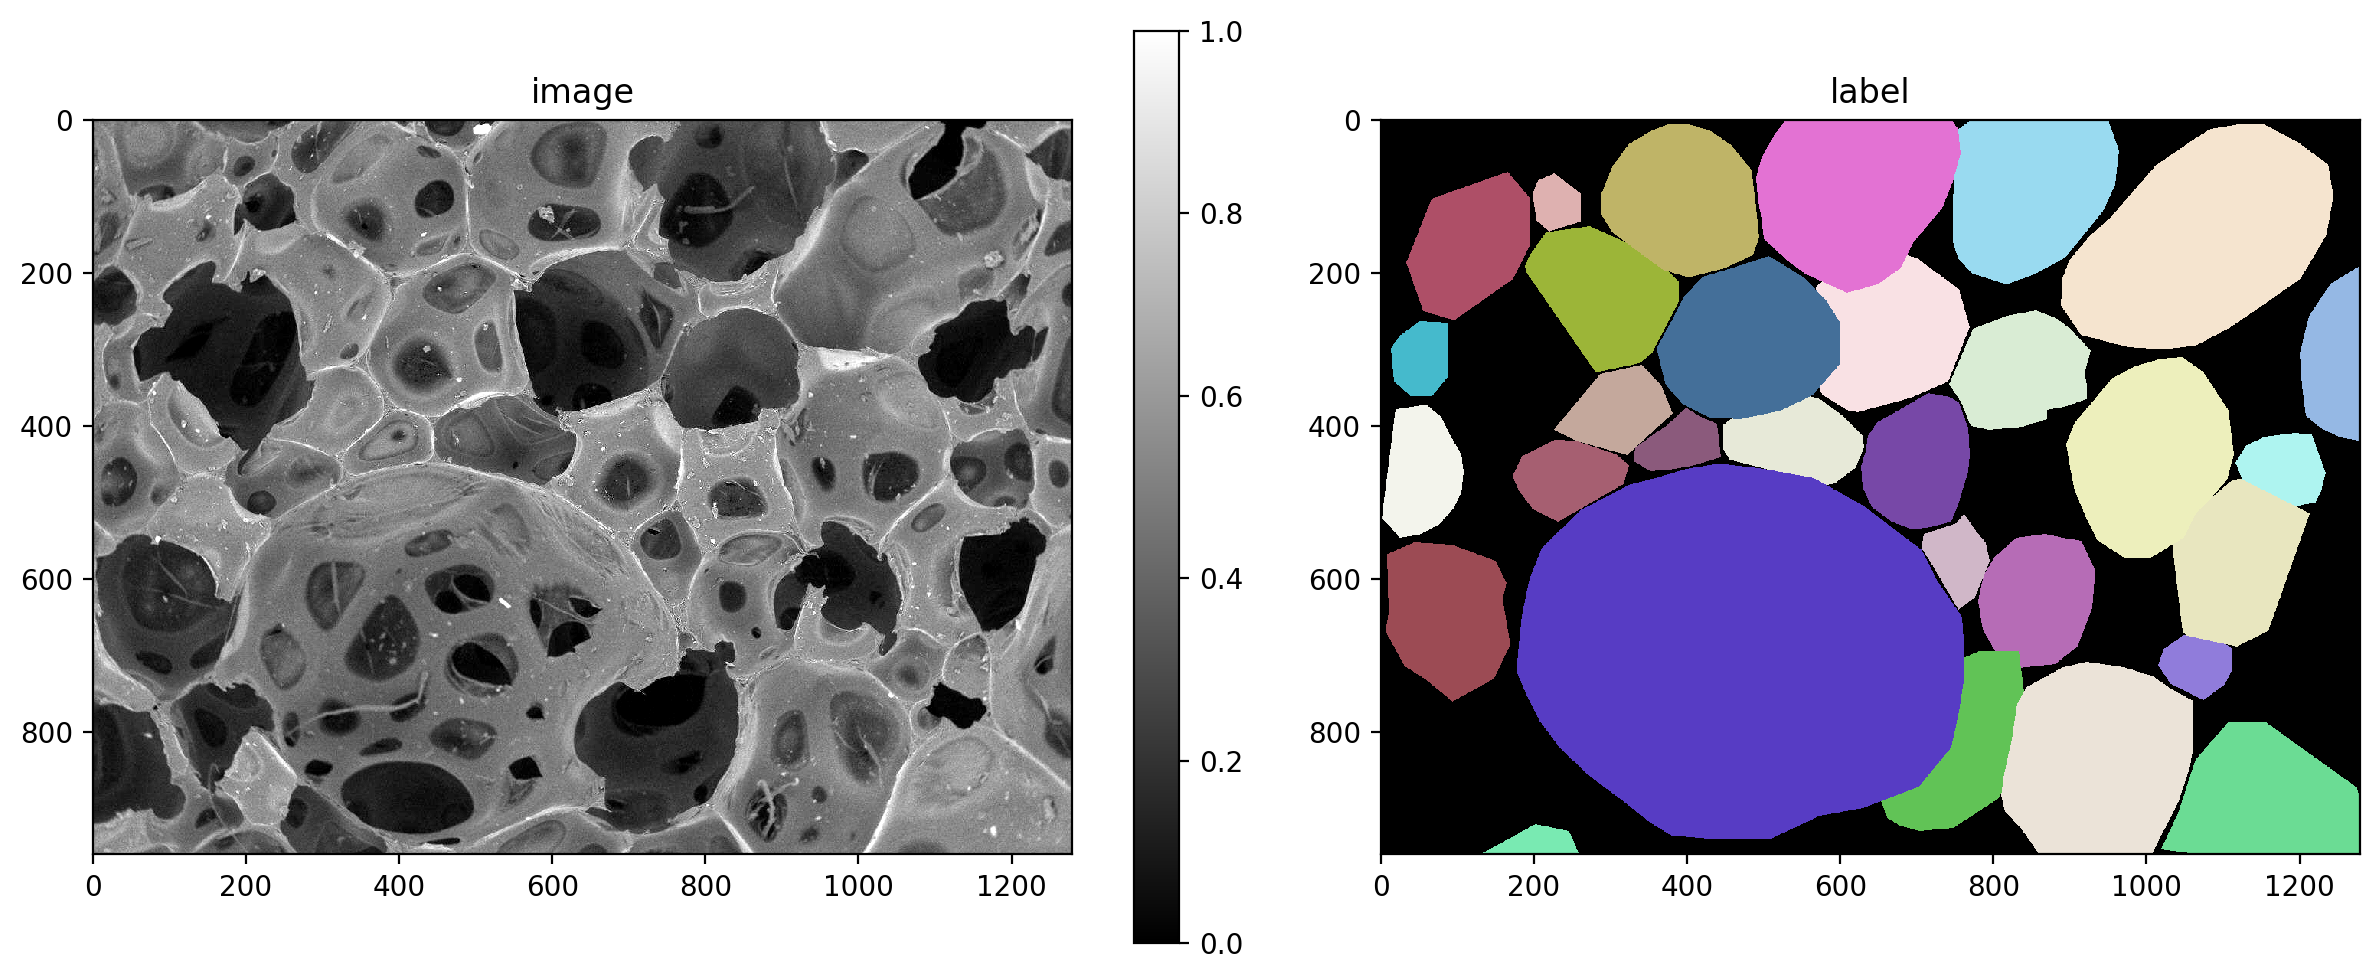

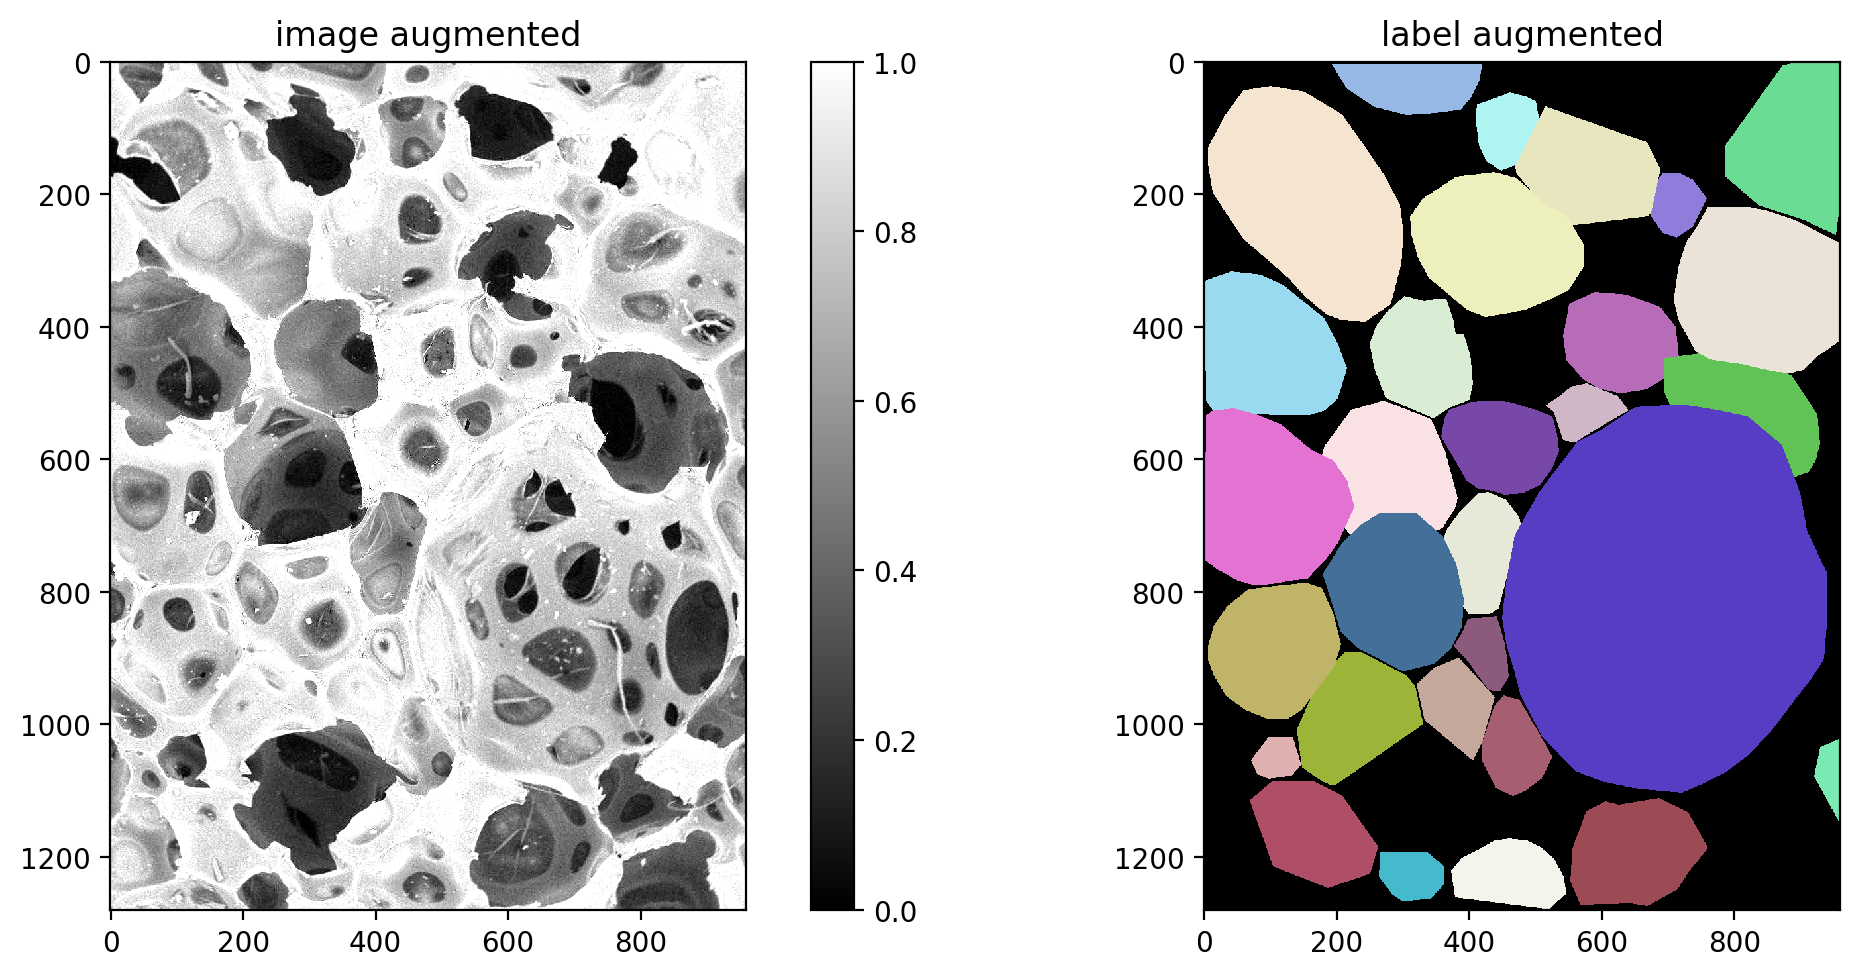

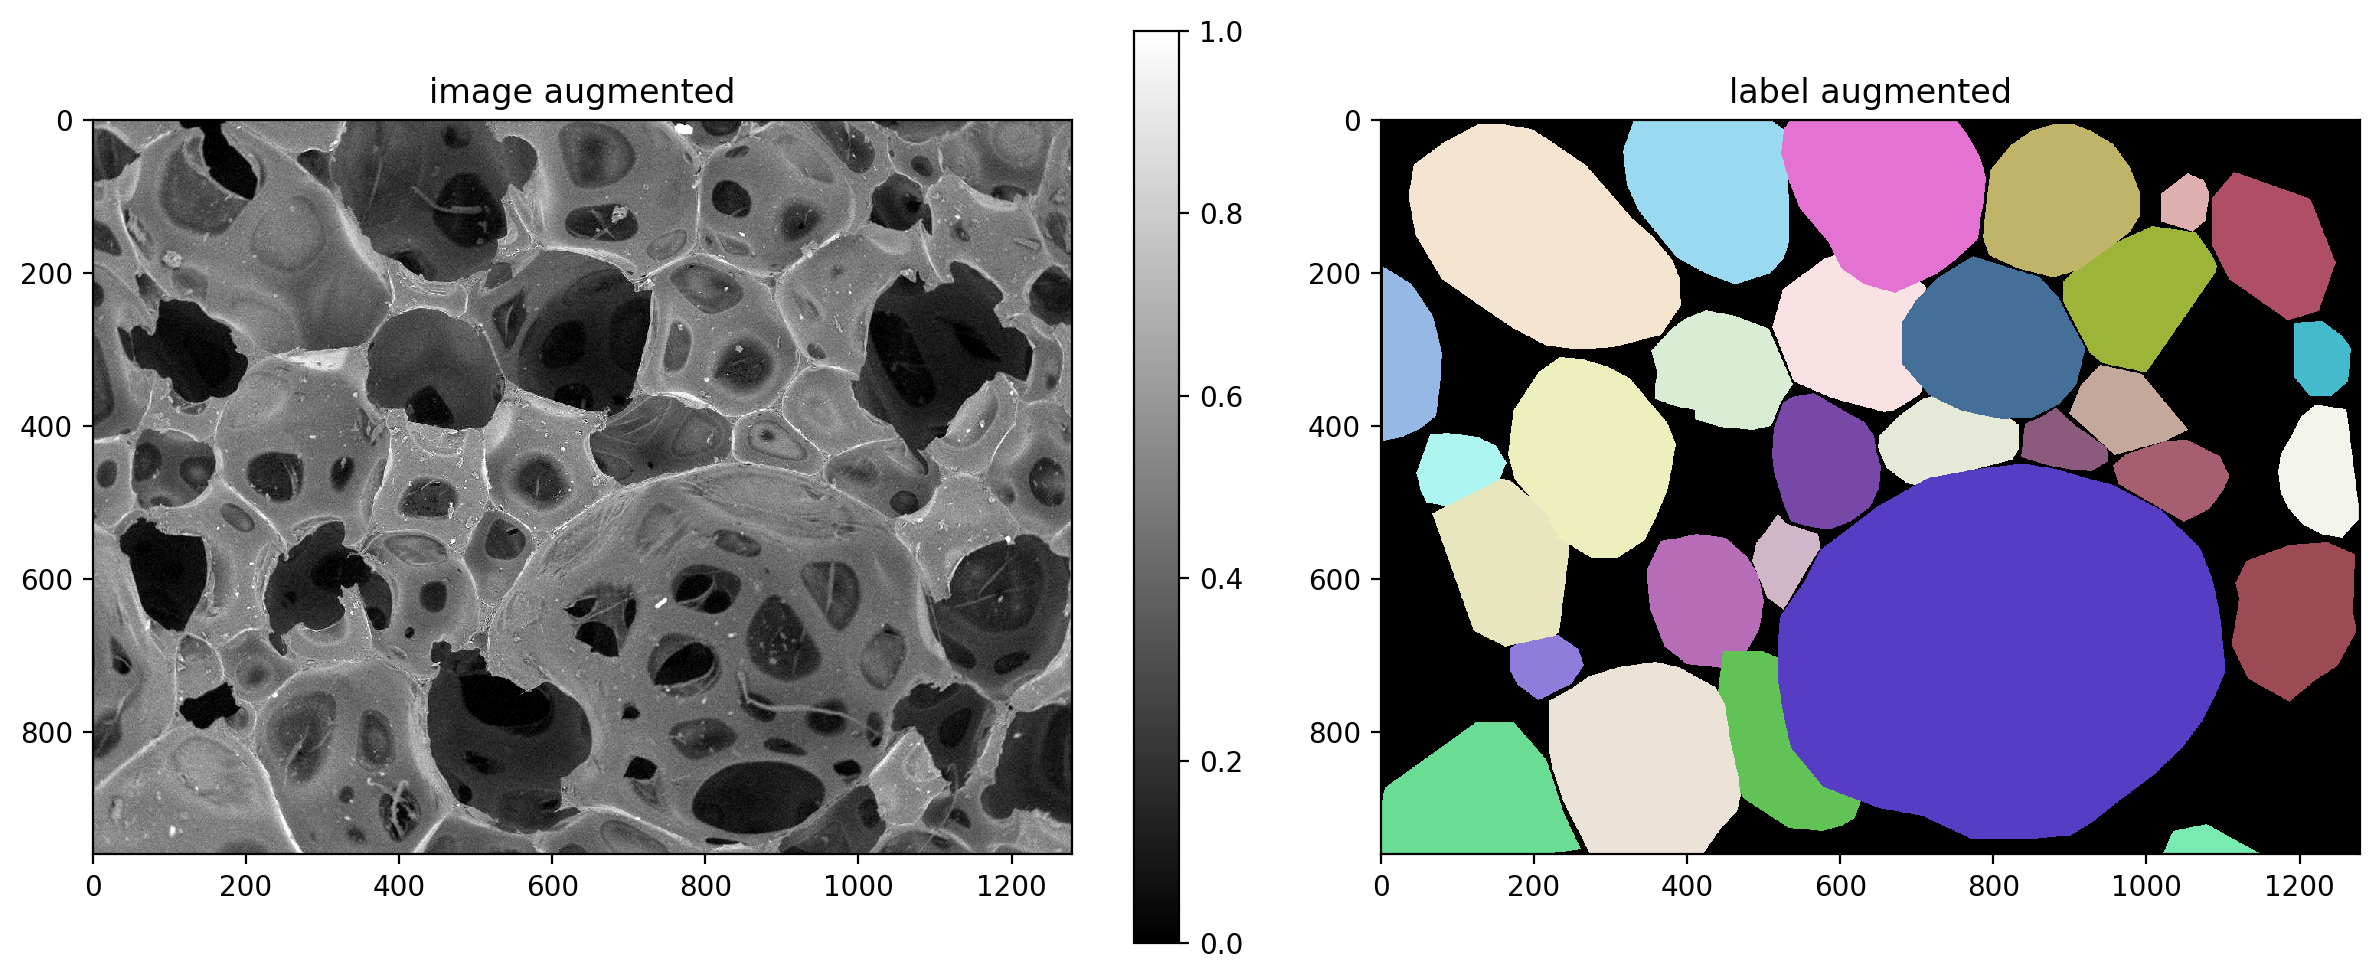

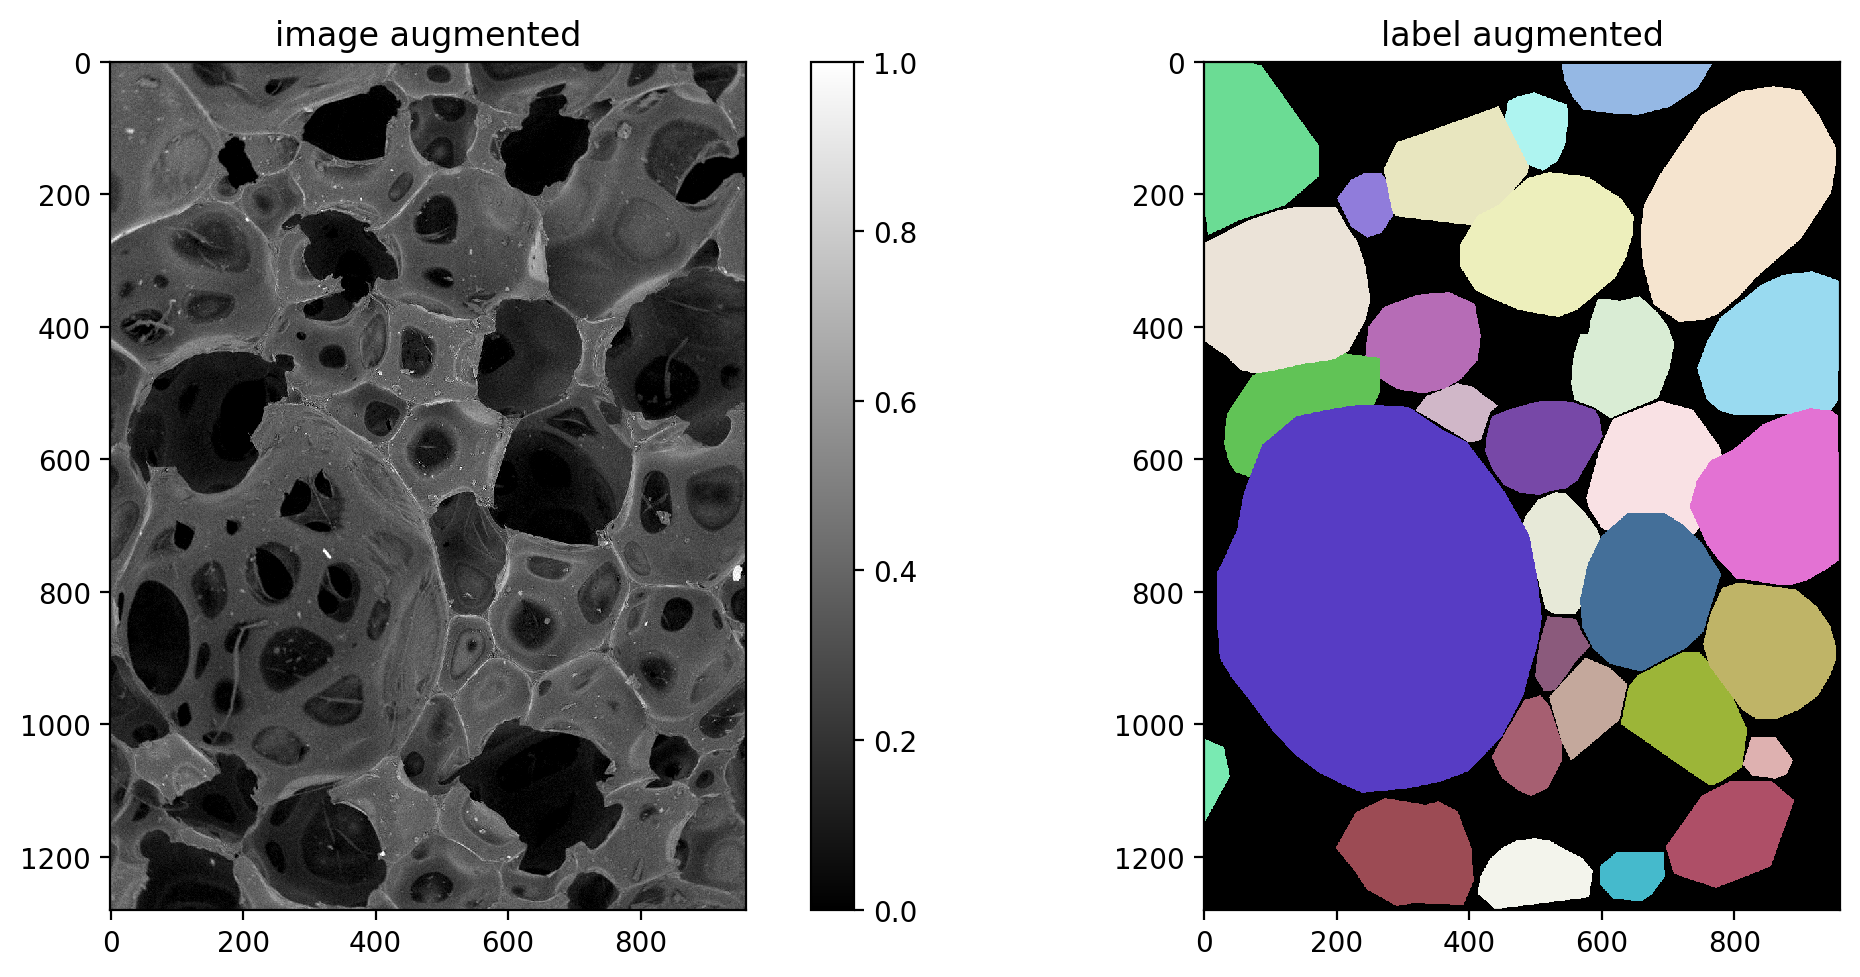

In [26]:
# plot some augmented examples
img, lbl = X_trn[0],Y_trn[0]
plot_img_label(img, lbl)
for _ in range(3):
    img_aug, lbl_aug = augmenter(img,lbl)
    plot_img_label(img_aug, lbl_aug, img_title="image augmented", lbl_title="label augmented")

# Training

We recommend to monitor the progress during training with [TensorBoard](https://www.tensorflow.org/programmers_guide/summaries_and_tensorboard). You can start it in the shell from the current working directory like this:

    $ tensorboard --logdir=.

Then connect to [http://localhost:6006/](http://localhost:6006/) with your browser.


In [30]:
!pip install "gputools<0.3" "numpy<2.0" "scipy<1.13"

INFO: pip is looking at multiple versions of reikna to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 2.9 MB/s eta 0:00:0000:0100:01
  Created wheel for reikna: filename=reikna-0.8.0-py3-none-any.whl size=122530 sha256=b830fb2f881b70f105141fee3193ed766318cf53434f065a66162bffb599822b
  Stored in directory: /root/.cache/pip/wheels/57/b5/21/046c0b1e0e4123625f66c2cb272bee599a3562d4e0c88495a0
Successfully built reikna
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
  Attempting uninstall: reikna
    Found existing install

In [27]:
quick_demo = False

if quick_demo:
    print (
        "NOTE: This is only for a quick demonstration!\n"
        "      Please set the variable 'quick_demo = False' for proper (long) training.",
        file=sys.stderr, flush=True
    )
    model.train(X_trn, Y_trn, validation_data=(X_val,Y_val), augmenter=augmenter,
                epochs=2, steps_per_epoch=10)

    print("====> Stopping training and loading previously trained demo model from disk.", file=sys.stderr, flush=True)
    model = StarDist2D.from_pretrained('2D_demo')
else:
    model.train(X_trn, Y_trn, validation_data=(X_val,Y_val), augmenter=augmenter)
None;

utils.py (107): EDT of constant label image is ill-defined. (Assuming background around it.)


Epoch 1/400


W0000 00:00:1778231076.708972     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.709308     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.709513     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.709958     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.710310     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.711565     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.713562     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.717485     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231076.718127     424 gp

  1/100 [..............................] - ETA: 10:32 - loss: 14.5455 - prob_loss: 0.6941 - dist_loss: 69.2569 - prob_kld: 0.2526 - dist_relevant_mae: 69.2569 - dist_relevant_mse: 7570.6074 - dist_dist_iou_metric: 1.6059e-09

W0000 00:00:1778231079.788604     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.788777     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.788888     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.789071     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.789272     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.789808     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.790059     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.790251     421 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231079.790503     421 gp

...

100/100 [==============================] - ETA: 0s - loss: 12.6870 - prob_loss: 0.8852 - dist_loss: 59.0092 - prob_kld: 0.4031 - dist_relevant_mae: 59.0068 - dist_relevant_mse: 6490.4448 - dist_dist_iou_metric: 0.1399     

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

100/100 [==============================] - 14s 80ms/step - loss: 12.6870 - prob_loss: 0.8852 - dist_loss: 59.0092 - prob_kld: 0.4031 - dist_relevant_mae: 59.0068 - dist_relevant_mse: 6490.4448 - dist_dist_iou_metric: 0.1399 - val_loss: 9.8767 - val_prob_loss: 0.6680 - val_dist_loss: 46.0432 - val_prob_kld: 0.1844 - val_dist_relevant_mae: 46.0403 - val_dist_relevant_mse: 4611.8271 - val_dist_dist_iou_metric: 0.2109 - lr: 3.0000e-04
Epoch 2/400
  1/100 [..............................] - ETA: 2s - loss: 9.3705 - prob_loss: 0.6687 - dist_loss: 43.5089 - prob_kld: 0.1947 - dist_relevant_mae: 43.5057 - dist_relevant_mse: 3880.6294 - dist_dist_iou_metric: 0.2087

W0000 00:00:1778231087.613505     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.613656     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.613784     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.613893     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.613983     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.614218     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.614403     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.614574     417 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778231087.615009     417 gp

100/100 [==============================] - 5s 47ms/step - loss: 9.7942 - prob_loss: 0.7608 - dist_loss: 45.1668 - prob_kld: 0.2795 - dist_relevant_mae: 45.1627 - dist_relevant_mse: 4187.0498 - dist_dist_iou_metric: 0.2721 - val_loss: 9.3302 - val_prob_loss: 0.7451 - val_dist_loss: 42.9253 - val_prob_kld: 0.2615 - val_dist_relevant_mae: 42.9222 - val_dist_relevant_mse: 4139.2500 - val_dist_dist_iou_metric: 0.2425 - lr: 3.0000e-04
Epoch 3/400
100/100 [==============================] - 4s 39ms/step - loss: 8.6312 - prob_loss: 0.8227 - dist_loss: 39.0429 - prob_kld: 0.3455 - dist_relevant_mae: 39.0387 - dist_relevant_mse: 3261.7949 - dist_dist_iou_metric: 0.3197 - val_loss: 7.9093 - val_prob_loss: 0.8340 - val_dist_loss: 35.3765 - val_prob_kld: 0.3504 - val_dist_relevant_mae: 35.3713 - val_dist_relevant_mse: 2632.6401 - val_dist_dist_iou_metric: 0.3976 - lr: 3.0000e-04
Epoch 4/400
100/100 [==============================] - 4s 38ms/step - loss: 8.1261 - prob_loss: 0.7565 - dist_loss: 36.847

In [28]:
# Below I ensure that model is properly saved

model.keras_model.save_weights(str(Path(model.logdir) / 'weights_final.h5'))

# Always run threshold optimization
model.optimize_thresholds(X_val, Y_val)

# Initial quick model check
from stardist.models import StarDist2D
model_loaded = StarDist2D(None, name='stardist', basedir='models')
test_pred, _ = model_loaded.predict_instances(
    X_val[0], n_tiles=model_loaded._guess_n_tiles(X_val[0])
)
print(f"Sanity check: pred={test_pred.max()}, GT={Y_val[0].max()}")  # should be close

W0000 00:00:1778232445.304335     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.304649     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.304973     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.305375     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.306062     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.306928     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.307411     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.307949     424 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778232445.308283     424 gp

Using optimized values: prob_thresh=0.479347, nms_thresh=0.3.
Saving to 'thresholds.json'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479347, nms_thresh=0.3.


W0000 00:00:1778233237.279981     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.280370     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.280598     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.281109     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.287560     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.288879     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.290173     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.290962     423 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778233237.291655     423 gp

Sanity check: pred=66, GT=35


In [32]:
import json

# Save thresholds manually
thresholds_dict = {
    'prob': float(model.thresholds.prob),
    'nms': float(model.thresholds.nms)
}
with open(Path(model.logdir) / 'thresholds.json', 'w') as f:
    json.dump(thresholds_dict, f)

print(f"Saved: {thresholds_dict}")

Zapisano: {'prob': 0.47934688418233584, 'nms': 0.3}


# Threshold optimization

While the default values for the probability and non-maximum suppression thresholds already yield good results in many cases, we still recommend to adapt the thresholds to your data. The optimized threshold values are saved to disk and will be automatically loaded with the model.

In [43]:
if quick_demo:
    model.optimize_thresholds(X_val[:2], Y_val[:2])
else:
    model.optimize_thresholds(X_val, Y_val)

W0000 00:00:1777325145.322130     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.322291     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.322357     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.322436     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.322522     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.322758     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.322929     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.323088     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777325145.323444     319 gp

Using optimized values: prob_thresh=0.464088, nms_thresh=0.3.


# Evaluation and Detection Performance

Besides the losses and metrics during training, we can also quantitatively evaluate the actual detection/segmentation performance on the validation data by considering objects in the ground truth to be correctly matched if there are predicted objects with overlap (here [intersection over union (IoU)](https://en.wikipedia.org/wiki/Jaccard_index)) beyond a chosen IoU threshold $\tau$.

The corresponding matching statistics (average overlap, accuracy, recall, precision, etc.) are typically of greater practical relevance than the losses/metrics computed during training (but harder to formulate as a loss function). 
The value of $\tau$ can be between 0 (even slightly overlapping objects count as correctly predicted) and 1 (only pixel-perfectly overlapping objects count) and which $\tau$ to use depends on the needed segmentation precision/application.

Please see `help(matching)` for definitions of the abbreviations used in the evaluation below and see the Wikipedia page on [Sensitivity and specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) for further details.

In [17]:
# help(matching)

First predict the labels for all validation images:

In [29]:
Y_val_pred = [model.predict_instances(x, n_tiles=model._guess_n_tiles(x), show_tile_progress=False)[0]
              for x in tqdm(X_val)]

100%|███████████████████████████████████████████████████████████████| 128/128 [00:58<00:00,  2.19it/s]


Plot a GT/prediction example 

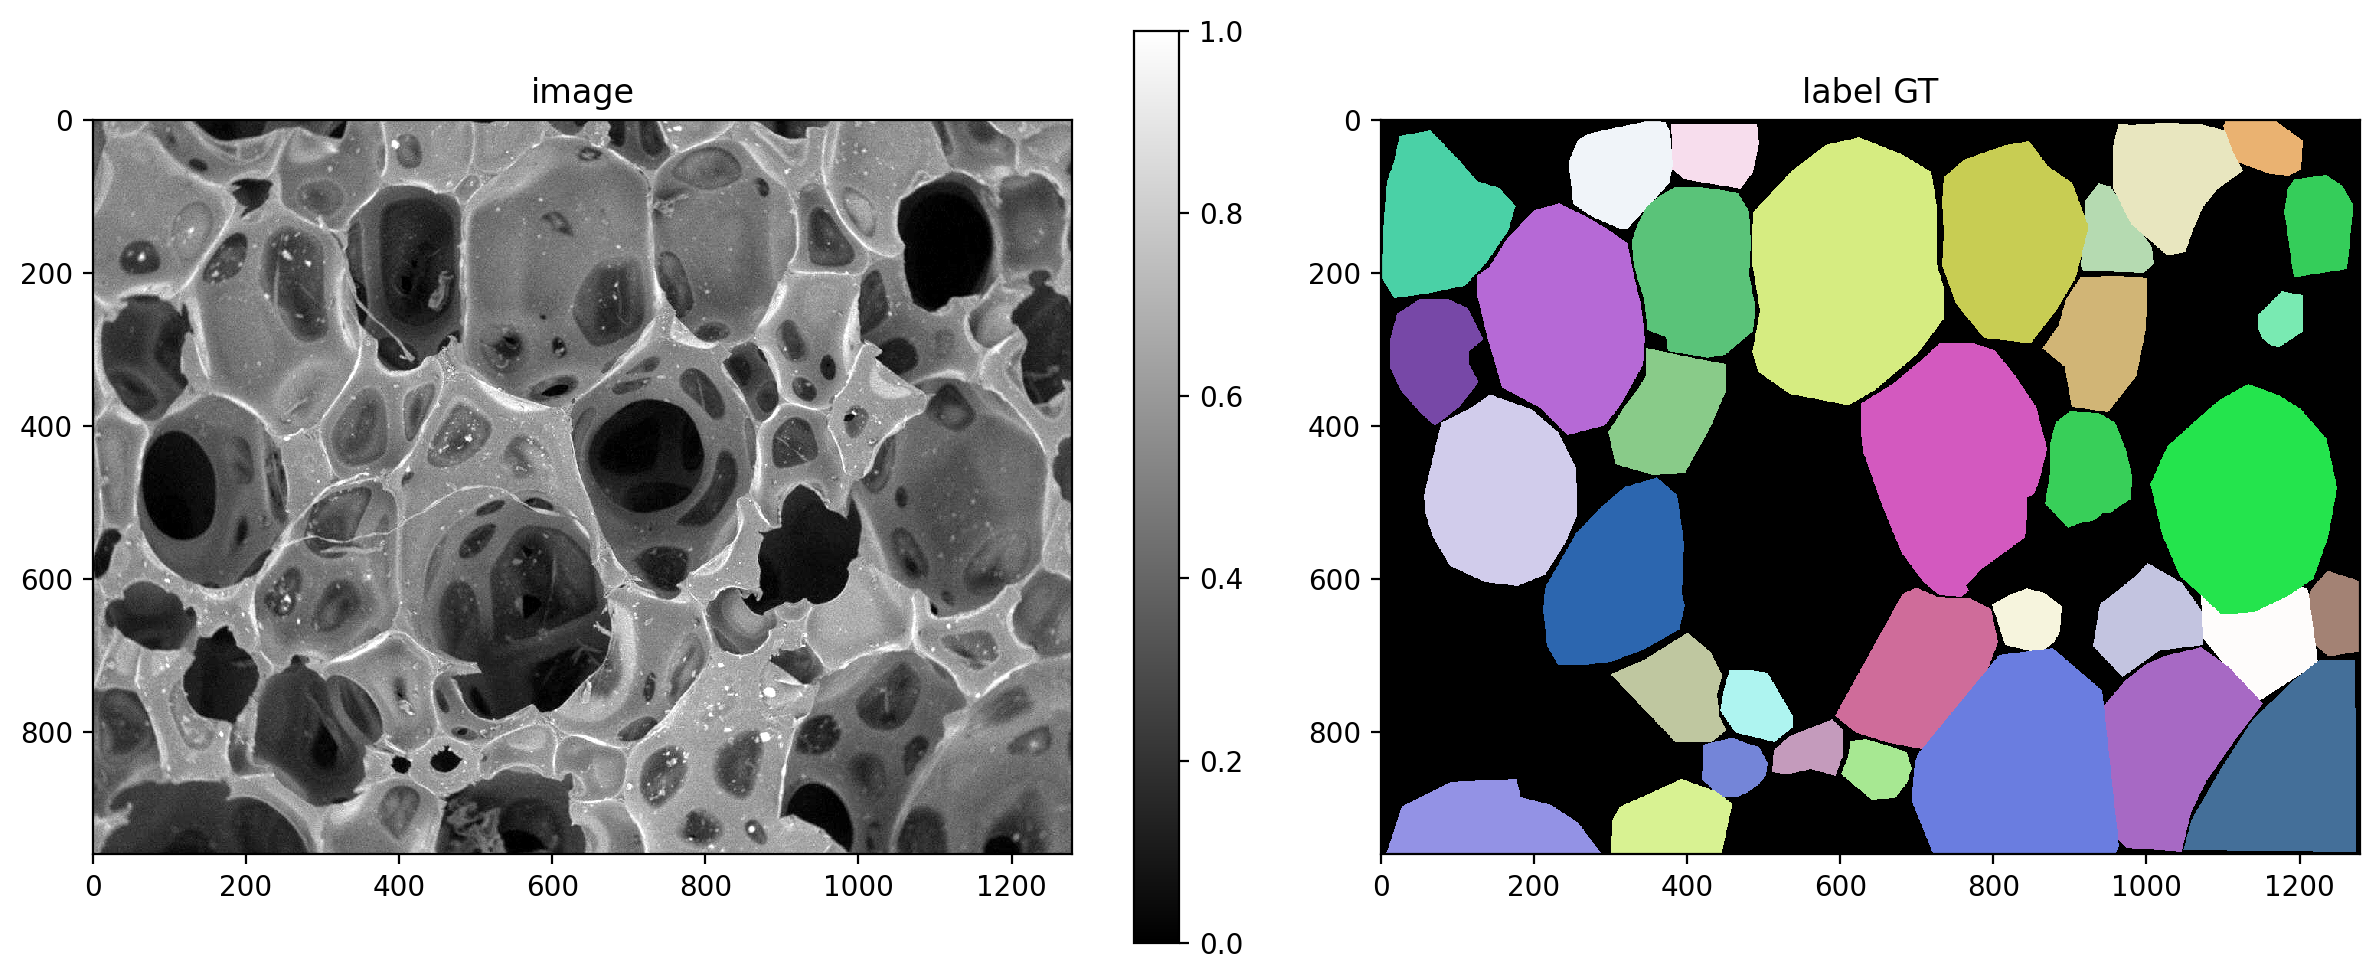

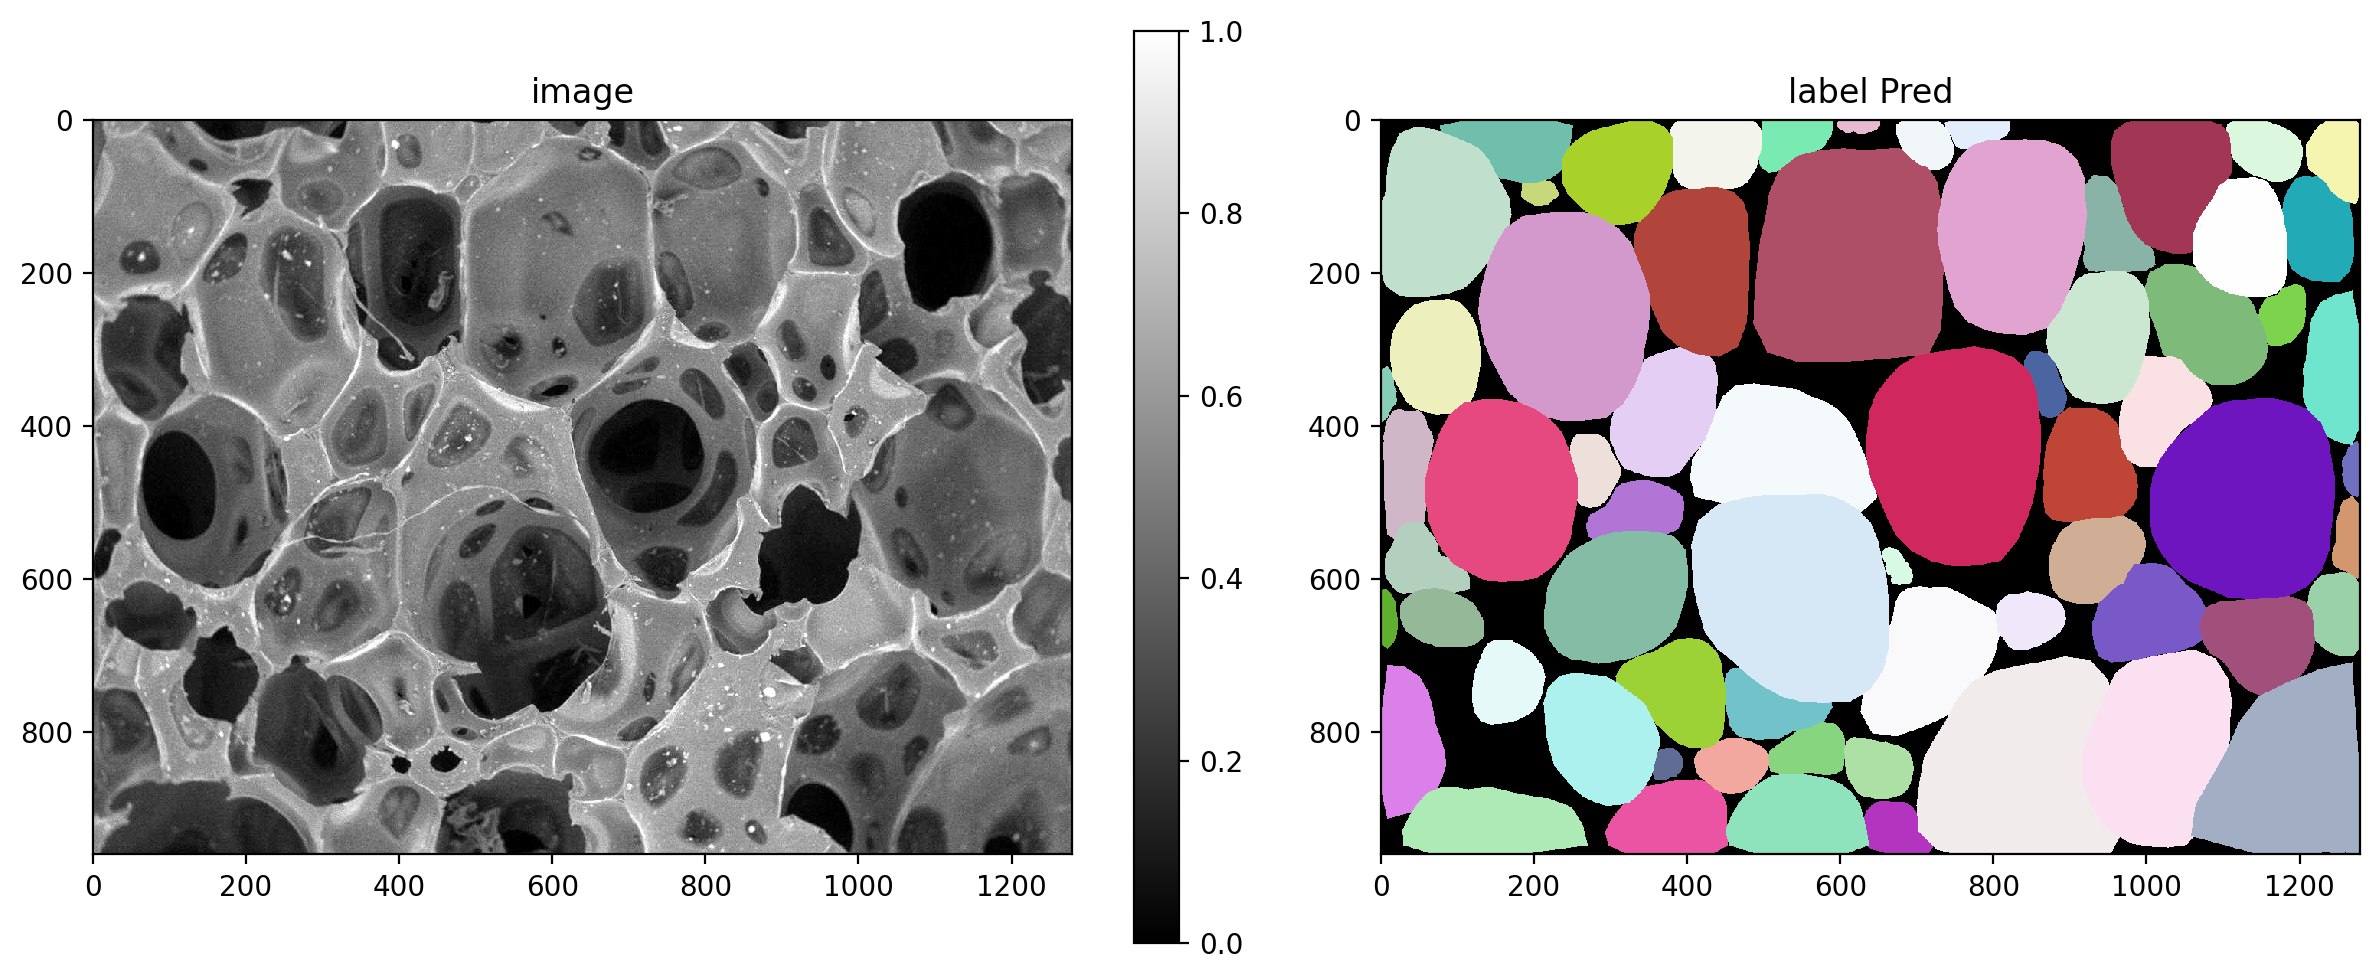

In [30]:
plot_img_label(X_val[0],Y_val[0], lbl_title="label GT")
plot_img_label(X_val[0],Y_val_pred[0], lbl_title="label Pred")

Choose several IoU thresholds $\tau$ that might be of interest and for each compute matching statistics for the validation data.

In [46]:
taus = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
stats = [matching_dataset(Y_val, Y_val_pred, thresh=t, show_progress=False) for t in tqdm(taus)]

100%|█████████████████████████████████████████████████████████████████████████████████████| 9/9 [01:57<00:00, 13.09s/it]


Example: Print all available matching statistics for $\tau=0.5$

In [47]:
stats[taus.index(0.5)]

DatasetMatching(criterion='iou', thresh=0.5, fp=2226, tp=4468, fn=906, precision=0.667463400059755, recall=0.8314104949758094, accuracy=0.5878947368421052, f1=0.7404706662247266, n_true=5374, n_pred=6694, mean_true_score=0.6634018913626804, mean_matched_score=0.7979234029057843, panoptic_quality=0.590838873745947, by_image=False)

Plot the matching statistics and the number of true/false positives/negatives as a function of the IoU threshold $\tau$. 

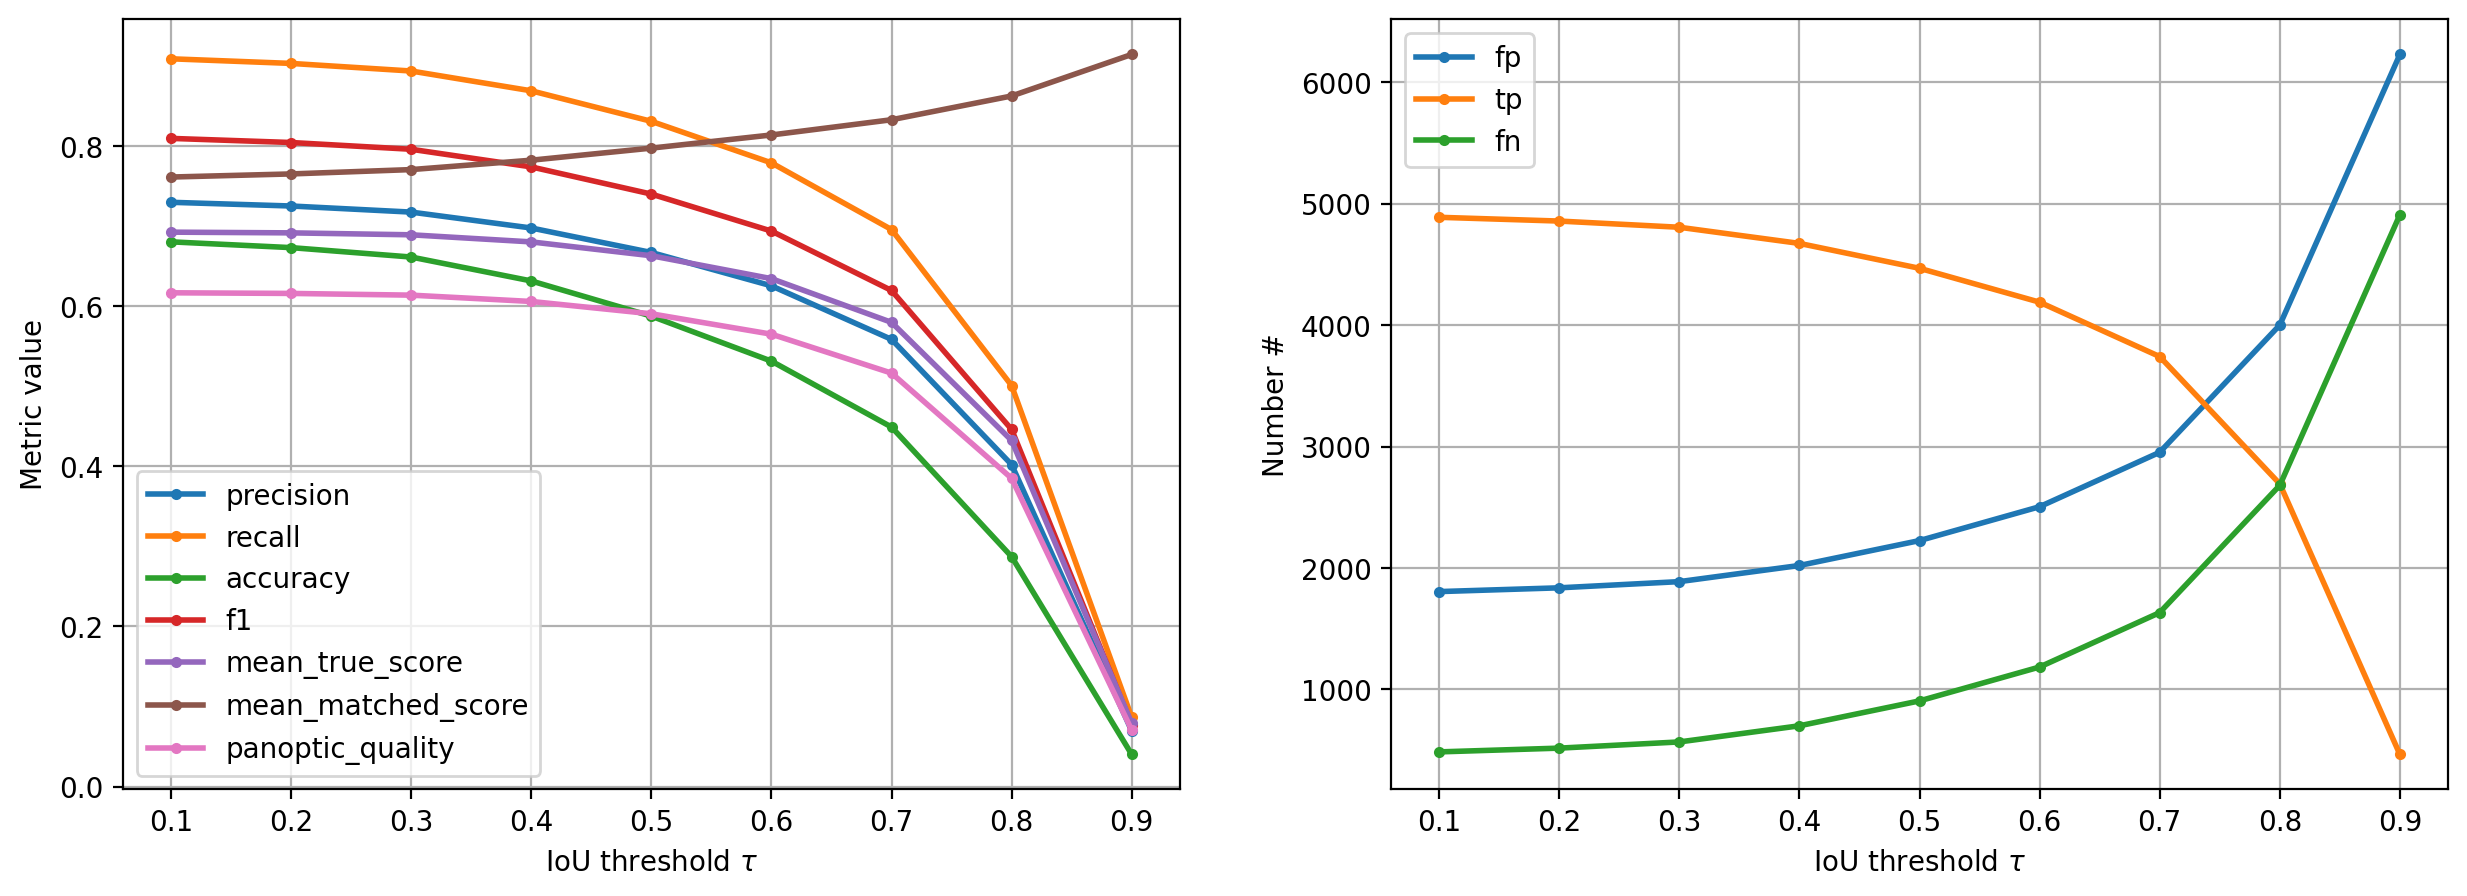

In [48]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15,5))

for m in ('precision', 'recall', 'accuracy', 'f1', 'mean_true_score', 'mean_matched_score', 'panoptic_quality'):
    ax1.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
ax1.set_xlabel(r'IoU threshold $\tau$')
ax1.set_ylabel('Metric value')
ax1.grid()
ax1.legend()

for m in ('fp', 'tp', 'fn'):
    ax2.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
ax2.set_xlabel(r'IoU threshold $\tau$')
ax2.set_ylabel('Number #')
ax2.grid()
ax2.legend();